### Data Management: Pandas

[Pandas](http://pandas.pydata.org/) is an open source library providing high-performance, easy-to-use data structures and data analysis tools. Pandas is particularly suited to the analysis of *tabular* data, i.e. data that can go into a table. In other words, if you can imagine the data in an Excel spreadsheet, then Pandas is the tool for the job.

- A fast and efficient DataFrame object for data manipulation with indexing
- Tools for reading and writing data: CSV, Excel, SQL
- Intelligent data alignment and integrated handling of missing data
- Flexible reshaping and pivoting of data sets
- Intelligent label-based slicing, indexing, and subsetting of large data sets
- High performance aggregating, merging, joining or transforming data
- Hierarchical indexing provides an intuitive way of working with high-dimensional data
- Time series-functionality: date-based indexing, frequency conversion, moving windows, date shifting and lagging

:::{.callout-note}
Documentation for this package is available at https://pandas.pydata.org/docs/.
:::

To use Pandas, you typically import it with the alias `pd`

In [1]:
import pandas as pd

We will also import NumPy as it is often used alongside Pandas for numerical operations.

In [2]:
import numpy as np

Pandas builds on two main data structures: `Series` and `DataFrames`.  `Series` represent 1D arrays while `DataFrames` are 2D labeled arrays.  The easiest way to think about both structures is to conceptualize `DataFrames` as containers of lower dimension data. That is, `DataFrames` columns are composed of `Series`, and each of the elements of a `Series` (i.e., the rows of the `DataFrame`) are individual scalar (numbers or strings) values. In plain words, `Series` are columns made of scalar elements and `DataFrames` are collections of `Series` that get an assigned label. 
All pandas data structures are value-mutable (i.e., we can change the values of elements and replace `DataFrames`) but some are not always size-mutable. The length of a Series cannot be changed, but, for example, columns can be inserted into a DataFrame.


#### Pandas Series

A `Series` is a one-dimensional labeled array capable of holding any data type (integers, strings, floating point numbers, Python objects, etc.). The axis labels are collectively referred to as the index. A `Series` can be created from a list, dictionary, or scalar value using the `pd.Series()` constructor. To create a `Series` from a list, you can do the following:

In [3]:
data = [10, 20, 30, 40, 50]
series = pd.Series(data)

If you want to specify custom index labels, you can pass a list of labels to the `index` parameter:

In [4]:
data = [10, 20, 30, 40, 50]
labels = ['a', 'b', 'c', 'd', 'e']
series = pd.Series(data, index=labels)

You can additionally assign a name to the `Series` using the `name` parameter:

In [5]:
data = [10, 20, 30, 40, 50]
labels = ['a', 'b', 'c', 'd', 'e']
series = pd.Series(data, index=labels, name='My Series')

These functions work the same way when creating a `Series` from a NumPy array. When creating a `Series` from a dictionary, the keys of the dictionary become the index labels, and the values become the data:

In [6]:
data = {'a': 10, 'b': 20, 'c': 30}
series = pd.Series(data)

You can access elements in a `Series` using their index labels or integer positions. For example, to access the element with label 'b':

In [7]:
value = series['b']
print("Value at index 'b':", value)

Value at index 'b': 20


If you want to access elements by their integer position, you can use the `iloc` attribute:

In [8]:
value = series.iloc[1]  # Access the second element (index 1)
print("Value at position 1:", value)

Value at position 1: 20


Note that both label-based and positional indexing can be used interchangeably in many cases.

`.loc` is used for label-based indexing, which means you access elements by their index labels:

| Syntax | Description | Example | Result |
|--------|-------------|---------|--------|
| `series.loc[label]` | Single label access | `s.loc['b']` | Value at index 'b' |
| `series.loc[label_list]` | Multiple labels | `s.loc[['a', 'c']]` | Series with values at 'a' and 'c' |
| `series.loc[start:end]` | Slice by labels (inclusive) | `s.loc['a':'c']` | Series from 'a' to 'c' (inclusive) |
| `series.loc[condition]` | Boolean indexing | `s.loc[s > 5]` | Values where condition is True |

`.iloc` is used for positional indexing, which means you access elements by their integer position in the Series:

| Syntax | Description | Example | Result |
|--------|-------------|---------|--------|
| `series.iloc[position]` | Single position access | `s.iloc[1]` | Value at position 1 |
| `series.iloc[position_list]` | Multiple positions | `s.iloc[[0, 2]]` | Series with values at positions 0 and 2 |
| `series.iloc[start:end]` | Slice by positions (exclusive end) | `s.iloc[1:3]` | Series from position 1 to 2 |
| `series.iloc[negative_pos]` | Negative indexing | `s.iloc[-1]` | Value at last position |

**Key Differences:**

1. Indexing method:
    - `.loc` uses the actual index labels (strings, dates, etc.)
    - `.iloc` uses integer positions (0, 1, 2, ...)
2. Slicing behavior:
    - `.loc` slicing is inclusive of both endpoints
    - `.iloc` slicing is exclusive of the end position


You can retrieve all index labels and values of a `Series` using the `index` and `values` attributes, respectively:

In [9]:
index_labels = series.index
print("Index labels:", index_labels)

Index labels: Index(['a', 'b', 'c'], dtype='object')


In [10]:
values = series.values
print("Values:", values)

Values: [10 20 30]


You can perform various operations on `Series`, such as arithmetic operations, aggregation functions, and filtering. For example, to add a scalar value to all elements in the `Series`:

In [11]:
new_series = series + 5
print("Series after adding 5:\n", new_series)

Series after adding 5:
 a    15
b    25
c    35
dtype: int64


You can also filter the `Series` based on a condition:

In [12]:
filtered_series = series[series > 20]
print("Filtered Series (values > 20):\n", filtered_series)

Filtered Series (values > 20):
 c    30
dtype: int64


They work and behave similarly to NumPy arrays in many ways but with additional functionality for handling missing data and labeled data.


#### Pandas DataFrames

Pandas Series are great for one-dimensional data, but in data science, we often work with two-dimensional data tables. This is where Pandas DataFrames come into play. A DataFrame is a two-dimensional labeled data structure with columns of potentially different types. You can think of it as a spreadsheet or SQL table, or a dictionary of Series objects.


##### Creating DataFrames

You can create a DataFrame from various data sources, such as dictionaries, lists of lists, or NumPy arrays. Here's an example of creating a DataFrame from a dictionary:

In [13]:
data = {
    'Name': ['Alba', 'Jesus', 'Yang'],
    'Age': [30, 25, 35],
    'City': ['New York', 'Los Angeles', 'Chicago']
}
df = pd.DataFrame(data)
df = df.set_index('Name')  # Set 'Name' as the index
print("DataFrame:\n", df)

DataFrame:
        Age         City
Name                   
Alba    30     New York
Jesus   25  Los Angeles
Yang    35      Chicago


You can also create a DataFrame from a list of lists:

In [14]:
# Creating a DataFrame from a list of lists
pd.DataFrame(
    data=[
        [1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]
    ],
    index=["R1", "R2", "R3"],
    columns=["C1", "C2", "C3"]
)

,C1,C2,C3
R1,1,2,3
R2,4,5,6
R3,7,8,9


There are several more ways to create DataFrames, including from CSV files, Excel files, SQL databases, and more. Most of the time, you'll be loading data from external sources rather than creating DataFrames from scratch.

Indexing works similarly to Series, but now you have both row and column labels to consider. Here are some common ways to index and select data in a DataFrame:

| Method | Description |
|---|---|
| `df[column_label]` or `df.column_label` or `df.loc[:, column_label]` | Access a single column by label (returns a Series) |
| `df[[col1, col2]]` | Access multiple columns by label (returns a DataFrame) |
| `df.loc[row_labels, column_labels]` | Access rows and columns by **label** (names) |
| `df.iloc[row_positions, column_positions]` | Access rows and columns by **position** (integers) |
| `df[boolean_condition]` | Filter rows based on a boolean condition |


Consider the following DataFrame

In [15]:
df = pd.DataFrame(
    data={
        "area":           ["USA", "Eurozone", "Japan", "UK", "Canada", "Australia"],
        "year":           [2024, 2024, 2024, 2024, 2024, 2024],
        "gdp_growth":     [2.1, 1.3, 0.7, 1.5, 1.8, 2.0],      # in percent
        "inflation":      [3.2, 2.5, 1.0, 2.8, 2.2, 2.6],      # in percent
        "policy_rate":    [5.25, 4.00, -0.10, 5.00, 4.75, 4.35], # in percent
        "unemployment":   [3.8, 6.5, 2.6, 4.2, 5.1, 4.0],      # in percent
        "fx_usd":         [1.00, 1.09, 143.5, 0.79, 1.36, 1.51] # USD per unit of local currency
    },
    index=["A", "B", "C", "D", "E", "F"]
)
df

,area,year,gdp_growth,inflation,policy_rate,unemployment,fx_usd
A,USA,2024,2.1,3.2,5.25,3.8,1.00
B,Eurozone,2024,1.3,2.5,4.00,6.5,1.09
C,Japan,2024,0.7,1.0,-0.10,2.6,143.50
D,UK,2024,1.5,2.8,5.00,4.2,0.79
E,Canada,2024,1.8,2.2,4.75,5.1,1.36
F,Australia,2024,2.0,2.6,4.35,4.0,1.51


First, we will set the "areas" column as the index of the DataFrame. This will allow us to access rows by area name. We can do this using the `set_index()` method. 

In [16]:
df = df.set_index("area")

We could also do it in-place (modifying the original DataFrame directly)

```python
df.set_index("area", inplace=True)
```


##### Inspecting DataFrames

You can inspect the first few rows of a DataFrame using the `head()` method and the last few rows using the `tail()` method. By default, both methods display 5 rows, but you can specify a different number as an argument.

In [17]:
df.head()  # First 5 rows

,year,gdp_growth,inflation,policy_rate,unemployment,fx_usd
area,,,,,,
USA,2024,2.1,3.2,5.25,3.8,1.00
Eurozone,2024,1.3,2.5,4.00,6.5,1.09
Japan,2024,0.7,1.0,-0.10,2.6,143.50
UK,2024,1.5,2.8,5.00,4.2,0.79
Canada,2024,1.8,2.2,4.75,5.1,1.36


In [18]:
df.tail(3)  # Last 3 rows

,year,gdp_growth,inflation,policy_rate,unemployment,fx_usd
area,,,,,,
UK,2024,1.5,2.8,5.00,4.2,0.79
Canada,2024,1.8,2.2,4.75,5.1,1.36
Australia,2024,2.0,2.6,4.35,4.0,1.51


You can get a summary of the DataFrame using the `info()` method, which provides information about the index, columns, data types, and memory usage.

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6 entries, USA to Australia
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   year          6 non-null      int64  
 1   gdp_growth    6 non-null      float64
 2   inflation     6 non-null      float64
 3   policy_rate   6 non-null      float64
 4   unemployment  6 non-null      float64
 5   fx_usd        6 non-null      float64
dtypes: float64(5), int64(1)
memory usage: 336.0+ bytes


You can get basic statistical details of the DataFrame using the `describe()` method, which provides measures like mean, standard deviation, min, max, and quartiles for numerical columns.

In [20]:
df.describe()

,year,gdp_growth,inflation,policy_rate,unemployment,fx_usd
count,6.0,6.000000,6.000000,6.000000,6.000000,6.000000
mean,2024.0,1.566667,2.383333,3.875000,4.366667,24.875000
std,0.0,0.520256,0.754763,1.998187,1.318585,58.114711
min,2024.0,0.700000,1.000000,-0.100000,2.600000,0.790000
25%,2024.0,1.350000,2.275000,4.087500,3.850000,1.022500
50%,2024.0,1.650000,2.550000,4.550000,4.100000,1.225000
75%,2024.0,1.950000,2.750000,4.937500,4.875000,1.472500
max,2024.0,2.100000,3.200000,5.250000,6.500000,143.500000


##### Indexing and Selecting DataFrames

We can get a single column as a Series using python's getitem syntax on the DataFrame object.

In [21]:
df['inflation'] # returns a series

area
USA          3.2
Eurozone     2.5
Japan        1.0
UK           2.8
Canada       2.2
Australia    2.6
Name: inflation, dtype: float64

In [22]:
type(df['inflation'])

pandas.core.series.Series

...or using attribute syntax.

In [23]:
df.inflation  # returns a series

area
USA          3.2
Eurozone     2.5
Japan        1.0
UK           2.8
Canada       2.2
Australia    2.6
Name: inflation, dtype: float64

If we use a list of column names, we get a DataFrame back

In [24]:
df[['inflation']]  # returns a DataFrame

,inflation
area,
USA,3.2
Eurozone,2.5
Japan,1.0
UK,2.8
Canada,2.2
Australia,2.6


In [25]:
type(df[['inflation']])

pandas.core.frame.DataFrame

This is useful for selecting multiple columns at once.

In [26]:
df[['inflation', 'unemployment']]  # returns a dataframe with selected columns

,inflation,unemployment
area,,
USA,3.2,3.8
Eurozone,2.5,6.5
Japan,1.0,2.6
UK,2.8,4.2
Canada,2.2,5.1
Australia,2.6,4.0


We can use `.loc` to select rows and columns by label, and `.iloc` to select rows and columns by position.

- **`.loc`** uses labels (names) for both rows and columns. The syntax is `df.loc[rows, columns]`. Both can be single labels, lists, or slices. Slices with `.loc` are **inclusive** of the end.
- **`.iloc`** uses integer positions (like Python lists). The syntax is `df.iloc[rows, columns]`. Slices with `.iloc` are **exclusive** of the end (like standard Python slicing).

Suppose `df` looks like this:

| - | name  | age | city   |
|---|-------|-----|--------|
| 0 | Alice | 23  | Madrid |
| 1 | Bob   | 34  | London |
| 2 | Carol | 29  | Berlin |

- `df['age']` or `df.age` -> Series with ages.
- `df[['name', 'city']]` -> DataFrame with just name and city columns.
- `df.loc[1, 'city']` -> `'London'` (row label 1, column 'city').
- `df.loc[0:1, ['name', 'age']]` -> Rows 0 to 1, columns 'name' and 'age' (inclusive).
- `df.iloc[0:2, 1:3]` -> Rows 0 to 1, columns 1 and 2 (note that row 2 and column 3 are not included).
- `df[df['age'] > 25]` -> Rows where age is greater than 25.

As indicated above, both `.loc` and `.iloc` can take single labels/positions, lists of labels/positions, or slices. Here are some additional tips:

- Use `:` to select all rows or columns: 
    - `df.loc[:, 'age']` (all rows, 'age' column).
    - `df.iloc[1, :]` (row 1, all columns).
- Remember: `.loc` is label-based and **inclusive**; `.iloc` is position-based and **exclusive**.

In [27]:
df.loc["UK","gdp_growth"] # get the value in row "UK" and column "gdp_growth"

1.5

In [28]:
df.iloc[3,1] # get the value in row 3 and column 1 (recall: python uses zero-based index)

1.5

You can also get subsets of rows and columns using slices or lists

In [29]:
df.loc["USA":"UK",["policy_rate", "fx_usd"]] # Subset rows from "USA" to "UK" and columns "policy_rate" and "fx_usd"

,policy_rate,fx_usd
area,,
USA,5.25,1.00
Eurozone,4.00,1.09
Japan,-0.10,143.50
UK,5.00,0.79


We can filter rows based on a boolean condition.

In [30]:
df[df['unemployment'] > 5.0]  # returns a dataframe with rows where unemployment is greater than 5.0

,year,gdp_growth,inflation,policy_rate,unemployment,fx_usd
area,,,,,,
Eurozone,2024,1.3,2.5,4.00,6.5,1.09
Canada,2024,1.8,2.2,4.75,5.1,1.36


To filter rows in a DataFrame based on multiple conditions, you can use logical operators:

| Operator | Symbol | Meaning                                 | General Pattern                        |
|----------|--------|-----------------------------------------|----------------------------------------|
| AND      | `&`    | All conditions must be true             | `df[(condition1) & (condition2)]`      |
| OR       | `\|`   | At least one condition must be true     | `df[(condition1) \| (condition2)]`     |
| NOT      | `~`    | Negates a condition (condition is false)| `df[~(condition)]`                     |


You can combine these operators to build more complex filters as needed. For example

:::{python}
`df[(condition1 & condition2) | (~condition3 & condition4)]`
:::

To reduce the likelihood of mistakes, always enclose each condition in parentheses to ensure correct evaluation.

The following example filters the DataFrame to include only rows where the `fx_usd` is less than 1.0 **and** the `inflation` is greater than 2.0:

In [31]:
df[(df['fx_usd'] < 1.0) & (df["inflation"] > 2.0)]

,year,gdp_growth,inflation,policy_rate,unemployment,fx_usd
area,,,,,,
UK,2024,1.5,2.8,5.0,4.2,0.79


An alternative to boolean indexing is the `query()` method, which allows you to filter rows using a string expression. This can be more readable, especially for complex conditions:

In [32]:
df.query("fx_usd < 1.0 and inflation > 2.0")

,year,gdp_growth,inflation,policy_rate,unemployment,fx_usd
area,,,,,,
UK,2024,1.5,2.8,5.0,4.2,0.79


The `query()` method supports standard comparison operators (`<`, `>`, `==`, `!=`, `<=`, `>=`) and logical operators (`and`, `or`, `not`). You can also reference variables from the local environment using the `@` prefix:

In [33]:
threshold = 2.0
df.query("inflation > @threshold")

,year,gdp_growth,inflation,policy_rate,unemployment,fx_usd
area,,,,,,
USA,2024,2.1,3.2,5.25,3.8,1.00
Eurozone,2024,1.3,2.5,4.00,6.5,1.09
UK,2024,1.5,2.8,5.00,4.2,0.79
Canada,2024,1.8,2.2,4.75,5.1,1.36
Australia,2024,2.0,2.6,4.35,4.0,1.51


##### DataFrame Operations

There are many operations you can perform on DataFrames. Here are some common ones:

Adding Columns:

| Method         | Code Pattern (Abstraction)                | Notes                                      |
|----------------|------------------------------------------|--------------------------------------------|
| Direct assign  | `df[new_col] = values`                   | Adds or overwrites a column                |
| `assign()`     | `df.assign(new_col=values)`              | Adds a new column (returns a new DataFrame) |
| `insert()`     | `df.insert(loc, new_col, values)`        | Adds at specific position                  |
| Multiple cols  | `df[[col1, col2]] = values`              | Assign multiple columns at once            |


Adding Rows:

| Method      | Code Pattern (Abstraction)            | Notes                                         |
|-------------|--------------------------------------|-----------------------------------------------|
| `loc`       | `df.loc[new_label] = values`         | Adds or overwrites a row by index label       |
| `iloc`      | `df.iloc[position] = values`         | Overwrites a row at a specific integer position (does not add a new row) |
| `concat()`  | `df = pd.concat([df, new_rows_df])`  | Adds one or more new rows from another DataFrame |


For example, to add a new column that approximates real GDP growth (i.e., nominal GDP growth minus inflation):

In [34]:
df["real_gdp_growth"] = df.gdp_growth - df.inflation  # Create a new column as the difference between gdp_growth and inflation
df["avg_weather"] = [20.5, 18.0, 15.0, 12.5, 10.0, 22.0]  # Add a new column with average weather data
df

,year,gdp_growth,inflation,policy_rate,unemployment,fx_usd,real_gdp_growth,avg_weather
area,,,,,,,,
USA,2024,2.1,3.2,5.25,3.8,1.00,-1.1,20.5
Eurozone,2024,1.3,2.5,4.00,6.5,1.09,-1.2,18.0
Japan,2024,0.7,1.0,-0.10,2.6,143.50,-0.3,15.0
UK,2024,1.5,2.8,5.00,4.2,0.79,-1.3,12.5
Canada,2024,1.8,2.2,4.75,5.1,1.36,-0.4,10.0
Australia,2024,2.0,2.6,4.35,4.0,1.51,-0.6,22.0


Using `assign()`, we can do the same without modifying the original DataFrame (note that `assign()` returns a new DataFrame):

In [35]:
df = df.drop(columns=["real_gdp_growth"])  # Remove previously added column
df_new = df.assign(real_gdp_growth=df.gdp_growth - df.inflation)
df_new

,year,gdp_growth,inflation,policy_rate,unemployment,fx_usd,avg_weather,real_gdp_growth
area,,,,,,,,
USA,2024,2.1,3.2,5.25,3.8,1.00,20.5,-1.1
Eurozone,2024,1.3,2.5,4.00,6.5,1.09,18.0,-1.2
Japan,2024,0.7,1.0,-0.10,2.6,143.50,15.0,-0.3
UK,2024,1.5,2.8,5.00,4.2,0.79,12.5,-1.3
Canada,2024,1.8,2.2,4.75,5.1,1.36,10.0,-0.4
Australia,2024,2.0,2.6,4.35,4.0,1.51,22.0,-0.6


Using `insert()`, we can add a new column at a specific position. For example, to insert a `gdp_per_capita` column as the second column (index 1):

In [36]:
df.insert(
    loc=1,  # Insert at the second position (0-based index)
    column='gdp_per_capita',  # Name of the new column
    value=[60000, np.nan, 40000, np.nan, 55000, 70000]  # Values for the new column
)
df

,year,gdp_per_capita,gdp_growth,inflation,policy_rate,unemployment,fx_usd,avg_weather
area,,,,,,,,
USA,2024,60000.0,2.1,3.2,5.25,3.8,1.00,20.5
Eurozone,2024,NaN,1.3,2.5,4.00,6.5,1.09,18.0
Japan,2024,40000.0,0.7,1.0,-0.10,2.6,143.50,15.0
UK,2024,NaN,1.5,2.8,5.00,4.2,0.79,12.5
Canada,2024,55000.0,1.8,2.2,4.75,5.1,1.36,10.0
Australia,2024,70000.0,2.0,2.6,4.35,4.0,1.51,22.0


Deleting data:

| What to Remove         | Method/Option         | Code Pattern (Abstraction)                                 | Notes                                 |
|------------------------|----------------------|------------------------------------------------------------|---------------------------------------|
| Columns by label       | `drop()`             | `df.drop([col1, col2, ...], axis=1)`                       | Returns new DataFrame                 |
| Columns by label (in-place) | `drop()`        | `df.drop([col1, col2, ...], axis=1, inplace=True)`         | Modifies original DataFrame           |
| Columns by position    | `drop()`             | `df.drop(df.columns[[pos1, pos2, ...]], axis=1)`           | Use integer positions                 |
| Columns with missing values | `dropna()`      | `df.dropna(axis=1)`                                        | Removes columns with any missing      |
| Rows by label          | `drop()`             | `df.drop([row1, row2, ...], axis=0)`                       | Returns new DataFrame                 |
| Rows by label (in-place) | `drop()`           | `df.drop([row1, row2, ...], axis=0, inplace=True)`         | Modifies original DataFrame           |
| Rows by position       | `drop()`             | `df.drop(df.index[[pos1, pos2, ...]], axis=0)`             | Use integer positions                 |
| Rows with missing values | `dropna()`         | `df.dropna(axis=0)`                                        | Removes rows with any missing         |
| Duplicate rows         | `drop_duplicates()`  | `df.drop_duplicates()`                                     | Removes duplicate rows                |


For example, to remove the `avg_weather` column we just added

In [37]:
df.drop("avg_weather", axis=1)

,year,gdp_per_capita,gdp_growth,inflation,policy_rate,unemployment,fx_usd
area,,,,,,,
USA,2024,60000.0,2.1,3.2,5.25,3.8,1.00
Eurozone,2024,NaN,1.3,2.5,4.00,6.5,1.09
Japan,2024,40000.0,0.7,1.0,-0.10,2.6,143.50
UK,2024,NaN,1.5,2.8,5.00,4.2,0.79
Canada,2024,55000.0,1.8,2.2,4.75,5.1,1.36
Australia,2024,70000.0,2.0,2.6,4.35,4.0,1.51


We can also drop columns with NaN values

In [38]:
df.dropna(axis=1)  # Drops columns with any NaN values

,year,gdp_growth,inflation,policy_rate,unemployment,fx_usd,avg_weather
area,,,,,,,
USA,2024,2.1,3.2,5.25,3.8,1.00,20.5
Eurozone,2024,1.3,2.5,4.00,6.5,1.09,18.0
Japan,2024,0.7,1.0,-0.10,2.6,143.50,15.0
UK,2024,1.5,2.8,5.00,4.2,0.79,12.5
Canada,2024,1.8,2.2,4.75,5.1,1.36,10.0
Australia,2024,2.0,2.6,4.35,4.0,1.51,22.0


Or fill it up with default "fallback" data:

In [39]:
df.fillna(df.gdp_per_capita.median())  # Fills NaN values with the median of the gdp_per_capita column

,year,gdp_per_capita,gdp_growth,inflation,policy_rate,unemployment,fx_usd,avg_weather
area,,,,,,,,
USA,2024,60000.0,2.1,3.2,5.25,3.8,1.00,20.5
Eurozone,2024,57500.0,1.3,2.5,4.00,6.5,1.09,18.0
Japan,2024,40000.0,0.7,1.0,-0.10,2.6,143.50,15.0
UK,2024,57500.0,1.5,2.8,5.00,4.2,0.79,12.5
Canada,2024,55000.0,1.8,2.2,4.75,5.1,1.36,10.0
Australia,2024,70000.0,2.0,2.6,4.35,4.0,1.51,22.0


Note that both `drop()` and `fillna()` return a new DataFrame by default. Thus, when we access `df` again, we will see that it still contains the `avg_weather` column and any NaN values. 

In [40]:
df  # Original DataFrame remains unchanged

,year,gdp_per_capita,gdp_growth,inflation,policy_rate,unemployment,fx_usd,avg_weather
area,,,,,,,,
USA,2024,60000.0,2.1,3.2,5.25,3.8,1.00,20.5
Eurozone,2024,NaN,1.3,2.5,4.00,6.5,1.09,18.0
Japan,2024,40000.0,0.7,1.0,-0.10,2.6,143.50,15.0
UK,2024,NaN,1.5,2.8,5.00,4.2,0.79,12.5
Canada,2024,55000.0,1.8,2.2,4.75,5.1,1.36,10.0
Australia,2024,70000.0,2.0,2.6,4.35,4.0,1.51,22.0


We can also sort the entries in dataframes, e.g. alphabetically by index or numerically by column values

| What to Sort         | Method/Option         | Code Pattern (Abstraction)                       | Notes                                      |
|----------------------|----------------------|--------------------------------------------------|--------------------------------------------|
| By column(s)         | `sort_values()`      | `df.sort_values(by=col)`                         | Sort by one column (ascending by default)  |
| By multiple columns  | `sort_values()`      | `df.sort_values(by=[col1, col2])`                | Sort by several columns (priority order)   |
| By column(s), descending | `sort_values()`  | `df.sort_values(by=col, ascending=False)`         | Sort in descending order                   |
| By multiple columns, custom order | `sort_values()` | `df.sort_values(by=[col1, col2], ascending=[True, False])` | Custom order for each column      |
| By index             | `sort_index()`       | `df.sort_index()`                                | Sort by row index (ascending by default)   |
| By index, descending | `sort_index()`       | `df.sort_index(ascending=False)`                 | Sort index in descending order             |
| By columns (column labels) | `sort_index()` | `df.sort_index(axis=1)`                          | Sort columns by their labels               |
| By columns, descending | `sort_index()`     | `df.sort_index(axis=1, ascending=False)`         | Sort columns in descending order           |

For example, to sort the DataFrame by `inflation` in descending order

In [41]:
df.sort_values(by='inflation', ascending=False)

,year,gdp_per_capita,gdp_growth,inflation,policy_rate,unemployment,fx_usd,avg_weather
area,,,,,,,,
USA,2024,60000.0,2.1,3.2,5.25,3.8,1.00,20.5
UK,2024,NaN,1.5,2.8,5.00,4.2,0.79,12.5
Australia,2024,70000.0,2.0,2.6,4.35,4.0,1.51,22.0
Eurozone,2024,NaN,1.3,2.5,4.00,6.5,1.09,18.0
Canada,2024,55000.0,1.8,2.2,4.75,5.1,1.36,10.0
Japan,2024,40000.0,0.7,1.0,-0.10,2.6,143.50,15.0


To sort by multiple columns, e.g., first by `year` (ascending) and then by `gdp_growth` (descending):

In [42]:
df.sort_values(by=['year', 'gdp_growth'], ascending=[True, False])

,year,gdp_per_capita,gdp_growth,inflation,policy_rate,unemployment,fx_usd,avg_weather
area,,,,,,,,
USA,2024,60000.0,2.1,3.2,5.25,3.8,1.00,20.5
Australia,2024,70000.0,2.0,2.6,4.35,4.0,1.51,22.0
Canada,2024,55000.0,1.8,2.2,4.75,5.1,1.36,10.0
UK,2024,NaN,1.5,2.8,5.00,4.2,0.79,12.5
Eurozone,2024,NaN,1.3,2.5,4.00,6.5,1.09,18.0
Japan,2024,40000.0,0.7,1.0,-0.10,2.6,143.50,15.0


We can also sort by index

In [43]:
df.sort_index()

,year,gdp_per_capita,gdp_growth,inflation,policy_rate,unemployment,fx_usd,avg_weather
area,,,,,,,,
Australia,2024,70000.0,2.0,2.6,4.35,4.0,1.51,22.0
Canada,2024,55000.0,1.8,2.2,4.75,5.1,1.36,10.0
Eurozone,2024,NaN,1.3,2.5,4.00,6.5,1.09,18.0
Japan,2024,40000.0,0.7,1.0,-0.10,2.6,143.50,15.0
UK,2024,NaN,1.5,2.8,5.00,4.2,0.79,12.5
USA,2024,60000.0,2.1,3.2,5.25,3.8,1.00,20.5


or column names

In [44]:
df.sort_index(axis=1)

,avg_weather,fx_usd,gdp_growth,gdp_per_capita,inflation,policy_rate,unemployment,year
area,,,,,,,,
USA,20.5,1.00,2.1,60000.0,3.2,5.25,3.8,2024
Eurozone,18.0,1.09,1.3,NaN,2.5,4.00,6.5,2024
Japan,15.0,143.50,0.7,40000.0,1.0,-0.10,2.6,2024
UK,12.5,0.79,1.5,NaN,2.8,5.00,4.2,2024
Canada,10.0,1.36,1.8,55000.0,2.2,4.75,5.1,2024
Australia,22.0,1.51,2.0,70000.0,2.6,4.35,4.0,2024


Pandas supports a wide range of methods for merging different datasets. These are described extensively in the [documentation](https://pandas.pydata.org/pandas-docs/stable/merging.html). Here we just give a few examples.

| Method | Function | Description | Key Parameters | Use Case |
|--------|----------|-------------|----------------|----------|
| **Inner Join** | `pd.merge(df1, df2, how='inner')` | Returns only rows with matching keys in both dataframes | `on`, `left_on`, `right_on` | When you only want records that exist in both datasets |
| **Left Join** | `pd.merge(df1, df2, how='left')` | Returns all rows from left dataframe, matching rows from right | `on`, `left_on`, `right_on` | Keep all records from primary dataset, add matching info |
| **Right Join** | `pd.merge(df1, df2, how='right')` | Returns all rows from right dataframe, matching rows from left | `on`, `left_on`, `right_on` | Keep all records from secondary dataset |
| **Outer Join** | `pd.merge(df1, df2, how='outer')` | Returns all rows from both dataframes | `on`, `left_on`, `right_on` | When you want all records from both datasets |
| **Cross Join** | `pd.merge(df1, df2, how='cross')` | Cartesian product of both dataframes | None required | Create all possible combinations |
| **Concat Vertical** | `pd.concat([df1, df2])` | Stacks dataframes vertically (rows) | `axis=0`, `ignore_index` | Combine datasets with same columns |
| **Concat Horizontal** | `pd.concat([df1, df2], axis=1)` | Joins dataframes horizontally (columns) | `axis=1`, `join` | Combine datasets with same index |
| **Join Method** | `df1.join(df2)` | Left join based on index | `how`, `lsuffix`, `rsuffix` | Quick join on index when columns don't overlap |


In [45]:
df_trade = pd.DataFrame({
    "area": ["USA", "Eurozone", "Japan", "China", "India", "Brazil"],
    "exports_bn": [1650, 2200, 705, 3360, 323, 281],
    "imports_bn": [2407, 2000, 641, 2601, 507, 219],
    "trade_balance": [-757, 200, 64, 759, -184, 62]
}).set_index("area")
df_trade

,exports_bn,imports_bn,trade_balance
area,,,
USA,1650,2407,-757
Eurozone,2200,2000,200
Japan,705,641,64
China,3360,2601,759
India,323,507,-184
Brazil,281,219,62


In [46]:
inner_result = pd.merge(df, df_trade, how='inner', left_index=True, right_index=True)
inner_result

,year,gdp_per_capita,gdp_growth,inflation,policy_rate,unemployment,fx_usd,avg_weather,exports_bn,imports_bn,trade_balance
area,,,,,,,,,,,
USA,2024,60000.0,2.1,3.2,5.25,3.8,1.00,20.5,1650,2407,-757
Eurozone,2024,NaN,1.3,2.5,4.00,6.5,1.09,18.0,2200,2000,200
Japan,2024,40000.0,0.7,1.0,-0.10,2.6,143.50,15.0,705,641,64


In [47]:
left_result = pd.merge(df, df_trade, how='left', left_index=True, right_index=True)
left_result

,year,gdp_per_capita,gdp_growth,inflation,policy_rate,unemployment,fx_usd,avg_weather,exports_bn,imports_bn,trade_balance
area,,,,,,,,,,,
USA,2024,60000.0,2.1,3.2,5.25,3.8,1.00,20.5,1650.0,2407.0,-757.0
Eurozone,2024,NaN,1.3,2.5,4.00,6.5,1.09,18.0,2200.0,2000.0,200.0
Japan,2024,40000.0,0.7,1.0,-0.10,2.6,143.50,15.0,705.0,641.0,64.0
UK,2024,NaN,1.5,2.8,5.00,4.2,0.79,12.5,NaN,NaN,NaN
Canada,2024,55000.0,1.8,2.2,4.75,5.1,1.36,10.0,NaN,NaN,NaN
Australia,2024,70000.0,2.0,2.6,4.35,4.0,1.51,22.0,NaN,NaN,NaN


In [48]:
right_result = pd.merge(df, df_trade, how='right', left_index=True, right_index=True)
right_result

,year,gdp_per_capita,gdp_growth,inflation,policy_rate,unemployment,fx_usd,avg_weather,exports_bn,imports_bn,trade_balance
area,,,,,,,,,,,
USA,2024.0,60000.0,2.1,3.2,5.25,3.8,1.00,20.5,1650,2407,-757
Eurozone,2024.0,NaN,1.3,2.5,4.00,6.5,1.09,18.0,2200,2000,200
Japan,2024.0,40000.0,0.7,1.0,-0.10,2.6,143.50,15.0,705,641,64
China,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3360,2601,759
India,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,323,507,-184
Brazil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,281,219,62


In [49]:
outer_result = pd.merge(df, df_trade, how='outer', left_index=True, right_index=True)
outer_result

,year,gdp_per_capita,gdp_growth,inflation,policy_rate,unemployment,fx_usd,avg_weather,exports_bn,imports_bn,trade_balance
area,,,,,,,,,,,
Australia,2024.0,70000.0,2.0,2.6,4.35,4.0,1.51,22.0,NaN,NaN,NaN
Brazil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,281.0,219.0,62.0
Canada,2024.0,55000.0,1.8,2.2,4.75,5.1,1.36,10.0,NaN,NaN,NaN
China,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3360.0,2601.0,759.0
Eurozone,2024.0,NaN,1.3,2.5,4.00,6.5,1.09,18.0,2200.0,2000.0,200.0
India,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,323.0,507.0,-184.0
Japan,2024.0,40000.0,0.7,1.0,-0.10,2.6,143.50,15.0,705.0,641.0,64.0
UK,2024.0,NaN,1.5,2.8,5.00,4.2,0.79,12.5,NaN,NaN,NaN
USA,2024.0,60000.0,2.1,3.2,5.25,3.8,1.00,20.5,1650.0,2407.0,-757.0


In [50]:
pd.concat([df, df_trade], axis=1).sort_index()  # Concatenate along columns

,year,gdp_per_capita,gdp_growth,inflation,policy_rate,unemployment,fx_usd,avg_weather,exports_bn,imports_bn,trade_balance
area,,,,,,,,,,,
Australia,2024.0,70000.0,2.0,2.6,4.35,4.0,1.51,22.0,NaN,NaN,NaN
Brazil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,281.0,219.0,62.0
Canada,2024.0,55000.0,1.8,2.2,4.75,5.1,1.36,10.0,NaN,NaN,NaN
China,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3360.0,2601.0,759.0
Eurozone,2024.0,NaN,1.3,2.5,4.00,6.5,1.09,18.0,2200.0,2000.0,200.0
India,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,323.0,507.0,-184.0
Japan,2024.0,40000.0,0.7,1.0,-0.10,2.6,143.50,15.0,705.0,641.0,64.0
UK,2024.0,NaN,1.5,2.8,5.00,4.2,0.79,12.5,NaN,NaN,NaN
USA,2024.0,60000.0,2.1,3.2,5.25,3.8,1.00,20.5,1650.0,2407.0,-757.0


In [51]:
pd.concat([df, df_trade], axis=0)  # Concatenate along rows

,year,gdp_per_capita,gdp_growth,inflation,policy_rate,unemployment,fx_usd,avg_weather,exports_bn,imports_bn,trade_balance
area,,,,,,,,,,,
USA,2024.0,60000.0,2.1,3.2,5.25,3.8,1.00,20.5,NaN,NaN,NaN
Eurozone,2024.0,NaN,1.3,2.5,4.00,6.5,1.09,18.0,NaN,NaN,NaN
Japan,2024.0,40000.0,0.7,1.0,-0.10,2.6,143.50,15.0,NaN,NaN,NaN
UK,2024.0,NaN,1.5,2.8,5.00,4.2,0.79,12.5,NaN,NaN,NaN
Canada,2024.0,55000.0,1.8,2.2,4.75,5.1,1.36,10.0,NaN,NaN,NaN
Australia,2024.0,70000.0,2.0,2.6,4.35,4.0,1.51,22.0,NaN,NaN,NaN
USA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1650.0,2407.0,-757.0
Eurozone,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2200.0,2000.0,200.0
Japan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,705.0,641.0,64.0


Sometimes it can be useful to apply a function to all values of a column/row. For instance, we might be interested in normalised inflation. We can do this using the `apply()` method. This method applies a function to each element in the Series or DataFrame.

In [52]:
df.inflation.apply(lambda x: (x - df.inflation.mean()) / df.inflation.std())  # Standardize the inflation column

area
USA          1.082018
Eurozone     0.154574
Japan       -1.832806
UK           0.552050
Canada      -0.242902
Australia    0.287066
Name: inflation, dtype: float64

Sometimes it is necessary to rename columns or indices in a DataFrame. There are several ways to do this, depending on whether you want to rename all columns, specific columns, or apply a function to transform the names.

| Method | Syntax | Use Case | Example |
|--------|--------|----------|---------|
| **Direct Assignment** | `df.columns = [list]` | Replace all column names at once | `df.columns = ['A', 'B', 'C']` |
| **rename() with Dictionary** | `df.rename(columns={dict})` | Rename specific columns selectively | `df.rename(columns={'old': 'new'})` |
| **rename() with inplace** | `df.rename(columns={dict}, inplace=True)` | Modify original DataFrame directly | `df.rename(columns={'old': 'new'}, inplace=True)` |
| **rename() with Function** | `df.rename(columns=function)` | Apply transformation to all columns | `df.rename(columns=str.upper)` |
| **String Methods** | `df.columns.str.method()` | Apply string operations to column names | `df.columns = df.columns.str.replace('_', ' ')` |
| **Lambda Function** | `df.rename(columns=lambda x: expression)` | Custom transformations on column names | `df.rename(columns=lambda x: x.replace('old', 'new'))` |

Key Parameters

| Parameter | Description | Default | Example |
|-----------|-------------|---------|---------|
| `columns` | Dictionary or function for column mapping | `None` | `{'old_name': 'new_name'}` |
| `inplace` | Modify DataFrame in place vs. return copy | `False` | `inplace=True` |
| `errors` | How to handle missing keys | `'ignore'` | `errors='raise'` |


In [53]:
df1 = df.copy()  # Create a copy of the DataFrame

df1 = df1.rename(columns={
    "gdp_growth": "gdp_growth_(%)",
    "gdp_per_capita": "gdp_per_capita_($)", 
    "inflation": "inflation_rate_(%)",
    "policy_rate": "policy_rate_(%)",
    "unemployment": "unemployment_rate_(%)",
    "fx_usd": "fx_rate_($/X)",
    "avg_weather": "avg_weather_(°C)",
    })  # Rename columns
df1

,year,gdp_per_capita_($),gdp_growth_(%),inflation_rate_(%),policy_rate_(%),unemployment_rate_(%),fx_rate_($/X),avg_weather_(°C)
area,,,,,,,,
USA,2024,60000.0,2.1,3.2,5.25,3.8,1.00,20.5
Eurozone,2024,NaN,1.3,2.5,4.00,6.5,1.09,18.0
Japan,2024,40000.0,0.7,1.0,-0.10,2.6,143.50,15.0
UK,2024,NaN,1.5,2.8,5.00,4.2,0.79,12.5
Canada,2024,55000.0,1.8,2.2,4.75,5.1,1.36,10.0
Australia,2024,70000.0,2.0,2.6,4.35,4.0,1.51,22.0


We can also work directly with column names

In [54]:
df1.columns = df.columns.str.replace('_', ' ')
df1 

,year,gdp per capita,gdp growth,inflation,policy rate,unemployment,fx usd,avg weather
area,,,,,,,,
USA,2024,60000.0,2.1,3.2,5.25,3.8,1.00,20.5
Eurozone,2024,NaN,1.3,2.5,4.00,6.5,1.09,18.0
Japan,2024,40000.0,0.7,1.0,-0.10,2.6,143.50,15.0
UK,2024,NaN,1.5,2.8,5.00,4.2,0.79,12.5
Canada,2024,55000.0,1.8,2.2,4.75,5.1,1.36,10.0
Australia,2024,70000.0,2.0,2.6,4.35,4.0,1.51,22.0


or the row names

In [55]:
# Capitalize the first letter of each area name
df1.index = df.index.str.upper() # Convert all area names to uppercase
df1.columns = df.columns.str.capitalize()  # Capitalize the first letter of each column name
df1

,Year,Gdp_per_capita,Gdp_growth,Inflation,Policy_rate,Unemployment,Fx_usd,Avg_weather
area,,,,,,,,
USA,2024,60000.0,2.1,3.2,5.25,3.8,1.00,20.5
EUROZONE,2024,NaN,1.3,2.5,4.00,6.5,1.09,18.0
JAPAN,2024,40000.0,0.7,1.0,-0.10,2.6,143.50,15.0
UK,2024,NaN,1.5,2.8,5.00,4.2,0.79,12.5
CANADA,2024,55000.0,1.8,2.2,4.75,5.1,1.36,10.0
AUSTRALIA,2024,70000.0,2.0,2.6,4.35,4.0,1.51,22.0


#### Data Visualization with Pandas

DataFrames have all kinds of [useful plotting](https://pandas.pydata.org/pandas-docs/stable/visualization.html) built in. Note that by default `matplotlib` is used as the backend for plotting in Pandas. However, Pandas imports matplotlib for you in the background and you don't have to do it yourself. 

You can create various types of plots directly from DataFrames and Series using the `plot()` method. Here are some examples:

<Axes: title={'center': 'GDP Growth by Area'}, xlabel='Area', ylabel='$ \\Delta y$ (%)'>

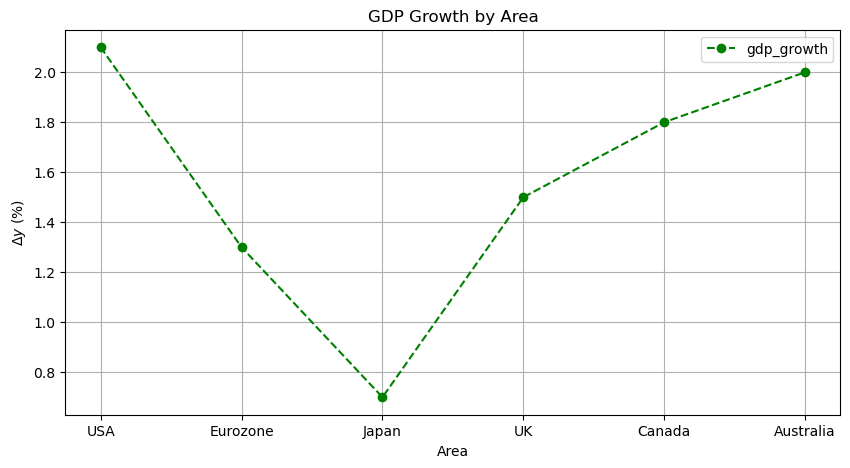

In [56]:
df.gdp_growth.plot(
  kind='line', 
  title='GDP Growth by Area',
  ylabel=r'$ \Delta y$ (%)',
  xlabel='Area', 
  grid=True, 
  figsize=(10, 5), 
  legend=True,
  color='green',
  marker='o',
  linestyle='--'
)

<Axes: title={'center': 'Inflation Rate by Area'}, xlabel='Area', ylabel='Inflation Rate (%)'>

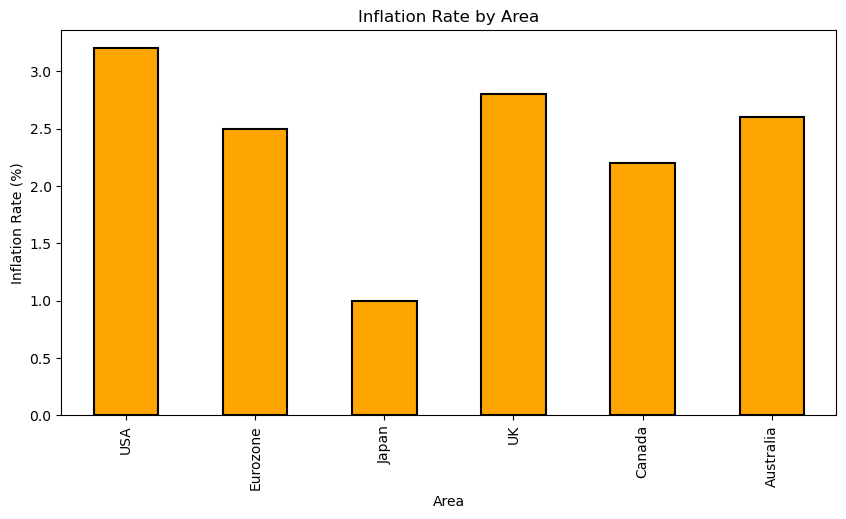

In [57]:
df.inflation.plot(
  kind='bar', 
  title='Inflation Rate by Area', 
  ylabel='Inflation Rate (%)', 
  xlabel='Area', 
  color="orange",
  grid=False,
  figsize=(10, 5),
  legend=False,
  edgecolor='black',
  linewidth=1.5
)

<Axes: title={'center': 'GDP Growth vs GDP per Capita'}, xlabel='GDP Growth (%)', ylabel='GDP per Capita ($)'>

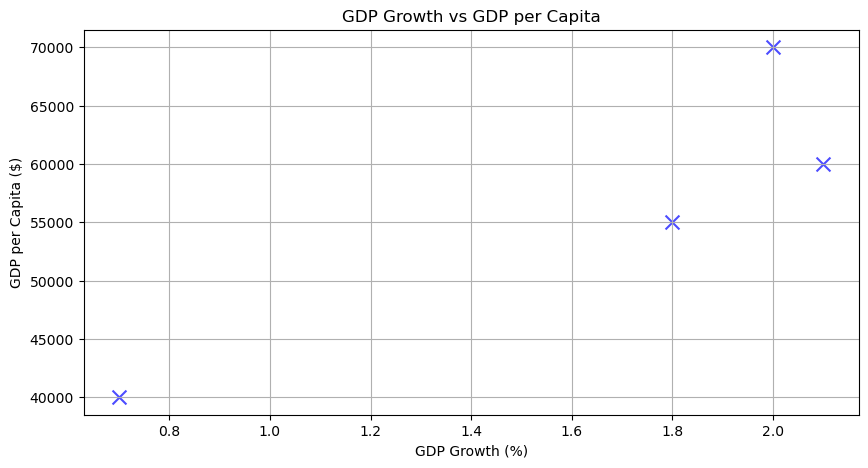

In [58]:
df.plot(
  kind="scatter", 
  x="gdp_growth", 
  y="gdp_per_capita", 
  title="GDP Growth vs GDP per Capita",
  xlabel="GDP Growth (%)",
  ylabel="GDP per Capita ($)",
  grid=True,
  figsize=(10, 5),
  color="blue",
  marker="x",
  s=100,  # Size of the markers
  alpha=0.7,  # Transparency of the markers
  linewidth=1.5 # Edge width of the markers
)  

#### Importing and Exporting Data

We have seen how to create DataFrames from scratch. However, in practice, we often need to load data from external files or databases. Pandas provides a variety of functions to read and write data in different formats. Data can be imported from CSV, Excel, and more. To read a CSV file into a DataFrame, you can use the `pd.read_csv()` function.

```python
file_csv ='./data.csv'
data = pd.read_csv(file_csv)
```

To read an Excel file, you can use the `pd.read_excel()` function.

```python
file_excel = './data.xlsx'
data = pd.read_excel(file_excel, sheet_name='Sheet1')
```

To write a DataFrame to a CSV file, you can use the `to_csv()` method.

```python
df.to_csv('output.csv', index=False)
```

To write a DataFrame to an Excel file, you can use the `to_excel()` method.

```python
df.to_excel('output.xlsx', sheet_name='Sheet1', index=False)
```

We will cover these and other data I/O methods in more detail in later sections of the course.



#### Grouping and Aggregating Data

One of the most powerful features of Pandas is the ability to group data by one or more columns and then apply aggregate functions to each group. This is done using the `groupby()` method, which splits the data into groups based on some criteria, applies a function to each group, and then combines the results.

In [59]:
# Create a sample DataFrame with multiple years
df_multi_year = pd.DataFrame({
    "area": ["USA", "USA", "Eurozone", "Eurozone", "Japan", "Japan"],
    "year": [2023, 2024, 2023, 2024, 2023, 2024],
    "gdp_growth": [2.5, 2.1, 0.9, 1.3, 1.2, 0.7],
    "inflation": [4.1, 3.2, 5.4, 2.5, 3.3, 1.0]
})
df_multi_year

,area,year,gdp_growth,inflation
0,USA,2023,2.5,4.1
1,USA,2024,2.1,3.2
2,Eurozone,2023,0.9,5.4
3,Eurozone,2024,1.3,2.5
4,Japan,2023,1.2,3.3
5,Japan,2024,0.7,1.0


To calculate the average GDP growth and inflation for each area across all years:

In [60]:
df_multi_year.groupby("area").mean()

,year,gdp_growth,inflation
area,,,
Eurozone,2023.5,1.10,3.95
Japan,2023.5,0.95,2.15
USA,2023.5,2.30,3.65


You can also apply multiple aggregation functions at once using `agg()`:

In [61]:
df_multi_year.groupby("area").agg({
    "gdp_growth": ["mean", "std"],
    "inflation": ["min", "max"]
})

gdp_growth           inflation     
               mean       std       min  max
area                                        
Eurozone       1.10  0.282843       2.5  5.4
Japan          0.95  0.353553       1.0  3.3
USA            2.30  0.282843       3.2  4.1

Grouping by multiple columns is also possible:

In [62]:
# Group by both area and whether gdp_growth is above 1%
df_multi_year["high_growth"] = df_multi_year["gdp_growth"] > 1.0
df_multi_year.groupby(["area", "high_growth"])["inflation"].mean()

area      high_growth
Eurozone  False          5.40
          True           2.50
Japan     False          1.00
          True           3.30
USA       True           3.65
Name: inflation, dtype: float64

The `groupby()` method is essential for data analysis tasks like computing summary statistics by category, creating pivot tables, and preparing data for visualization.


:::{.callout-tip}
### Scaling Beyond Pandas: PySpark

While Pandas excels at handling data that fits in memory, real-world big data applications often involve datasets too large for a single machine. [PySpark](https://spark.apache.org/docs/latest/api/python/) is the Python API for Apache Spark, a distributed computing framework that can process massive datasets across clusters of computers. PySpark DataFrames offer a similar interface to Pandas but distribute computations across many machines. For the purposes of this course, we will focus on Pandas, but it's worth noting that many concepts learned here can be transferred to PySpark when working with big data.
:::